Physics-Informed Neural Networks for the 1D Viscoelastic Wave Equation

PDE

$$
\rho u_{tt}=Eu_{xx}+\eta u_{xxt},
\qquad x\in[0,L],\ t\in[0,T]
$$

where $\rho$ is density, $E$ is elastic modulus, and $\eta$ is viscosity.

Boundary Conditions (BCs)

$$
u(0,t)=0,\qquad u(L,t)=0
$$

Initial Conditions (ICs)

$$
u(x,0)=\sin(kx),\qquad u_t(x,0)=0
$$

Analytical Solution

For the underdamped case, the solution is

$$
u(x,t)=e^{-\alpha t}
\left[
\cos(\omega_d t)+\frac{\alpha}{\omega_d}\sin(\omega_d t)
\right]\sin(kx),
$$

where

$$
\alpha=\frac{\eta k^2}{2\rho},
\qquad
\omega_d=
\sqrt{\frac{Ek^2}{\rho}-\alpha^2}.
$$

This analytical solution is used as the ground truth for validation.

Objectives

1. Solve the forward problem using a PINN for known $E$ and $\eta$.
2. Recover unknown $E$ and $\eta$ from sparse displacement measurements.
3. Compare PINN predictions with the analytical solution.

In [1]:
# dependencies & initial settings
!pip install deepxde -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import time
import json

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde
import torch

# reproducibility
SEED = 42
dde.config.set_random_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# plot style
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

OUTDIR = "/content/drive/MyDrive/PINN_example_13"
os.makedirs(OUTDIR, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.0 MB/s eta 0:00:00


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# physical parameters
rho = 1.0        # density
E_true = 4.0      # elastic modulus
eta_true = 0.1    # viscosity (ground truth)

L = 1.0           # domain length
T = 2.0           # total time
n_mode = 1        # no. of sinusiodal ICs

k = n_mode * np.pi / L
gamma = eta_true * k**2 / (2 * rho)
omega0_sq = E_true * k**2 / rho
omega_d = np.sqrt(omega0_sq - gamma**2)

In [3]:
# analytical solution
def analytical_solution(x, t):
    envelope = np.exp(-gamma * t) * (np.cos(omega_d * t) + (gamma / omega_d) * np.sin(omega_d * t))
    return envelope * np.sin(k * x)

def analytical_solution_dde(x):
    xs = x[:, 0:1]
    ts = x[:, 1:2]
    return analytical_solution(xs, ts)

In [4]:
# pde residual
def pde(x, u, E_param=E_true, eta_param=eta_true):
    du_tt = dde.grad.hessian(u, x, i=1, j=1)
    du_xx = dde.grad.hessian(u, x, i=0, j=0)
    du_xxt = dde.grad.jacobian(du_xx, x, i=0, j=1)
    return rho * du_tt - E_param * du_xx - eta_param * du_xxt

In [5]:
# spatio-temporal geometry
geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, T)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [6]:
# BCs & ICs
# u(0,t) = u(L,t) = 0
def boundary(x, on_boundary):
    return on_boundary and (np.isclose(x[0], 0) or np.isclose(x[0], L))
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, boundary)

# u(x,0) = sin(k x)
def ic_func(x):
    return np.sin(k * x[:, 0:1])
ic_disp = dde.icbc.IC(geomtime, ic_func, lambda _, on_initial: on_initial)
# u_t(x,0) = 0
def ic_velocity_operator(x, u, X):
    du_t = dde.grad.jacobian(u, x, i=0, j=1)
    return du_t
ic_vel = dde.icbc.OperatorBC(
    geomtime,
    ic_velocity_operator,
    lambda x, on_initial: on_initial,   # <-- fixed
)

In [7]:

def pde_forward(x, u):
    return pde(x, u, E_param=E_true, eta_param=eta_true)

In [8]:
# data and network objects
data_fwd = dde.data.TimePDE(
    geomtime,
    pde_forward,
    [bc, ic_disp, ic_vel],
    num_domain=4000,
    num_boundary=200,
    num_initial=400,
    solution=analytical_solution_dde,
    num_test=2006,  # bcz 2006 is my brthdy
)

layer_size = [2] + [50] * 4 + [1]
activation = "tanh"
initializer = "Glorot uniform"

def make_net():
    return dde.nn.FNN(layer_size, activation, initializer)

In [9]:
# plotting utilities
def get_test_grid(nx=200, nt=200):
    xs = np.linspace(0, L, nx)
    ts = np.linspace(0, T, nt)
    Xg, Tg = np.meshgrid(xs, ts, indexing="ij")
    XT = np.hstack([Xg.reshape(-1, 1), Tg.reshape(-1, 1)])
    return xs, ts, Xg, Tg, XT

def compute_errors(model, nx=200, nt=200):
    xs, ts, Xg, Tg, XT = get_test_grid(nx, nt)
    u_pred = model.predict(XT).reshape(Xg.shape)
    u_true = analytical_solution(Xg, Tg)
    err = u_pred - u_true
    l2_rel = np.linalg.norm(err) / np.linalg.norm(u_true)
    linf = np.max(np.abs(err))
    return dict(xs=xs, ts=ts, Xg=Xg, Tg=Tg, u_pred=u_pred, u_true=u_true,
                err=err, l2_rel=l2_rel, linf=linf)

def plot_loss_history(loss_history, title="Training loss history", fname=None,
                       loss_names=("PDE", "BC", "IC-disp", "IC-vel", "Data")):
    steps = np.array(loss_history.steps)
    train = np.array(loss_history.loss_train)
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
    n_terms = train.shape[1]
    for i in range(n_terms):
        label = loss_names[i] if i < len(loss_names) else f"term {i}"
        ax.semilogy(steps, train[:, i], label=label, lw=1.4)
    ax.semilogy(steps, train.sum(axis=1), label="Total", lw=2.0, color="k", ls="--")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(OUTDIR, fname))
    plt.show()

def plot_solution_maps(res, title_prefix="", fname=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, field, name, cmap in zip(
        axes, [res["u_pred"], res["u_true"], res["err"]],
        ["PINN prediction", "Analytical solution", "Pointwise error"],
        ["RdBu_r", "RdBu_r", "inferno"]
    ):
        vmax = np.max(np.abs(field)) if name != "Pointwise error" else None
        im = ax.pcolormesh(res["Tg"], res["Xg"], field, shading="auto", cmap=cmap,
                            vmin=-vmax if vmax else None, vmax=vmax)
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        ax.set_title(f"{title_prefix}{name}")
        fig.colorbar(im, ax=ax, shrink=0.85)
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(OUTDIR, fname))
    plt.show()

def plot_time_slices(res, times=(0.0, 0.5, 1.0, 1.5, 2.0), fname=None):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
    xs = res["xs"]
    for tt in times:
        idx = np.argmin(np.abs(res["ts"] - tt))
        ax.plot(xs, res["u_true"][:, idx], "k-", lw=1.6,
                label="Analytical" if tt == times[0] else None)
        ax.plot(xs, res["u_pred"][:, idx], "--", lw=1.6,
                label=f"PINN t={res['ts'][idx]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.set_title("Displacement profile at selected times")
    ax.legend(fontsize=8)
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(OUTDIR, fname))
    plt.show()

def plot_error_vs_time(res, fname=None):
    err_t = np.linalg.norm(res["err"], axis=0) / (np.linalg.norm(res["u_true"], axis=0) + 1e-12)
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
    ax.plot(res["ts"], err_t, lw=1.6, color="crimson")
    ax.set_xlabel("t")
    ax.set_ylabel("Relative L2 error (spatial)")
    ax.set_title("Error growth over time")
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(OUTDIR, fname))
    plt.show()

In [10]:
# plot after every n(2500) epochs, i.e a callback
class PeriodicPlotter(dde.callbacks.Callback):
    def __init__(self, period=100, plot_period=2000, nx=100, nt=100, tag="fwd"):
        super().__init__()
        self.period = period
        self.plot_period = plot_period
        self.nx, self.nt = nx, nt
        self.tag = tag
        self.epochs, self.loss_terms, self.l2_errors = [], [], []

    def on_epoch_end(self):
        it = self.model.train_state.step
        if it == 0 or it % self.period != 0:
            return
        losses = list(self.model.train_state.loss_train)
        self.epochs.append(it)
        self.loss_terms.append(losses)

        res = compute_errors(self.model, nx=self.nx, nt=self.nt)
        self.l2_errors.append(res["l2_rel"])
        print(f"[{self.tag}] it {it:6d} | losses: {['%.2e' % l for l in losses]} "
              f"| rel-L2 err: {res['l2_rel']:.3e}")

        if it % self.plot_period == 0:
            plot_solution_maps(res, title_prefix=f"it={it}: ",
                                fname=f"{self.tag}_snapshot_it{it}.png")

In [11]:
# adaptive rebalancing
class SoftAdaptiveWeights(dde.callbacks.Callback):
    def __init__(self, period=500, alpha=0.9, warmup=500):
        super().__init__()
        self.period = period
        self.alpha = alpha
        self.warmup = warmup
        self.history = []

    def on_epoch_end(self):
        it = self.model.train_state.step
        if it < self.warmup or it % self.period != 0:
            return
        losses = np.array(self.model.train_state.loss_train, dtype=float)
        raw = 1.0 / (losses + 1e-8)
        raw = raw / raw.sum() * len(losses)
        if not self.history:
            new_w = raw
        else:
            new_w = self.alpha * self.history[-1] + (1 - self.alpha) * raw
        self.history.append(new_w)
        self.model.loss_weights = list(new_w)
        print(f"it {it:6d} | updated loss_weights: {['%.3f' % w for w in new_w]}")

# resample collocation points each 100 epochs
resampler = dde.callbacks.PDEPointResampler(period=100)

Compiling model...
'compile' took 9.726918 s

Training model...



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step      Train loss                                  Test loss                                   Test metric   
0         [5.07e-03, 4.05e-05, 4.99e-01, 3.34e-04]    [4.97e-03, 4.05e-05, 4.99e-01, 3.34e-04]    [9.98e-01]    
[forward] it    100 | losses: ['5.07e-03', '4.05e-05', '4.99e-01', '3.34e-04'] | rel-L2 err: 1.163e+00
[forward] it    200 | losses: ['5.07e-03', '4.05e-05', '4.99e-01', '3.34e-04'] | rel-L2 err: 1.158e+00
[forward] it    300 | losses: ['5.07e-03', '4.05e-05', '4.99e-01', '3.34e-04'] | rel-L2 err: 1.105e+00
[forward] it    400 | losses: ['5.07e-03', '4.05e-05', '4.99e-01', '3.34e-04'] | rel-L2 err: 1.002e+00
500       [4.14e-03, 2.72e-02, 6.50e-02, 5.74e-02]    [3.83e-03, 2.72e-02, 6.50e-02, 5.74e-02]    [7.71e-01]    
[forward] it    500 | losses: ['4.14e-03', '2.72e-02', '6.50e-02', '5.74e-02'] | rel-L2 err: 9.598e-01
it    500 | updated loss_weights: ['3.105', '0.472', '0.198', '0.224']
[forward] it    600 | losses: ['4.14e-03', '2.72e-02', '6.50e-02', '5.74e-0

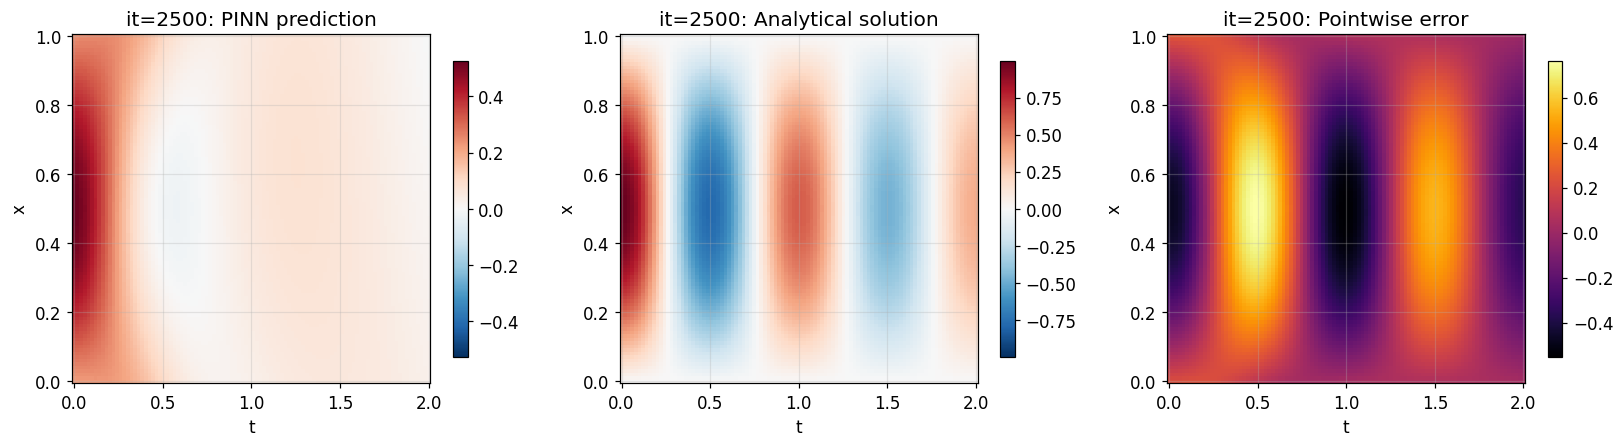

it   2500 | updated loss_weights: ['3.145', '0.450', '0.179', '0.226']
[forward] it   2600 | losses: ['6.98e-04', '6.05e-03', '1.74e-02', '1.20e-02'] | rel-L2 err: 8.982e-01
[forward] it   2700 | losses: ['6.98e-04', '6.05e-03', '1.74e-02', '1.20e-02'] | rel-L2 err: 9.043e-01
[forward] it   2800 | losses: ['6.98e-04', '6.05e-03', '1.74e-02', '1.20e-02'] | rel-L2 err: 8.959e-01
[forward] it   2900 | losses: ['6.98e-04', '6.05e-03', '1.74e-02', '1.20e-02'] | rel-L2 err: 8.992e-01
3000      [6.01e-04, 5.66e-03, 1.62e-02, 1.19e-02]    [5.04e-04, 5.66e-03, 1.62e-02, 1.19e-02]    [7.32e-01]    
[forward] it   3000 | losses: ['6.01e-04', '5.66e-03', '1.62e-02', '1.19e-02'] | rel-L2 err: 8.925e-01
it   3000 | updated loss_weights: ['3.165', '0.441', '0.173', '0.221']
[forward] it   3100 | losses: ['6.01e-04', '5.66e-03', '1.62e-02', '1.19e-02'] | rel-L2 err: 8.989e-01
[forward] it   3200 | losses: ['6.01e-04', '5.66e-03', '1.62e-02', '1.19e-02'] | rel-L2 err: 8.904e-01
[forward] it   3300 | lo

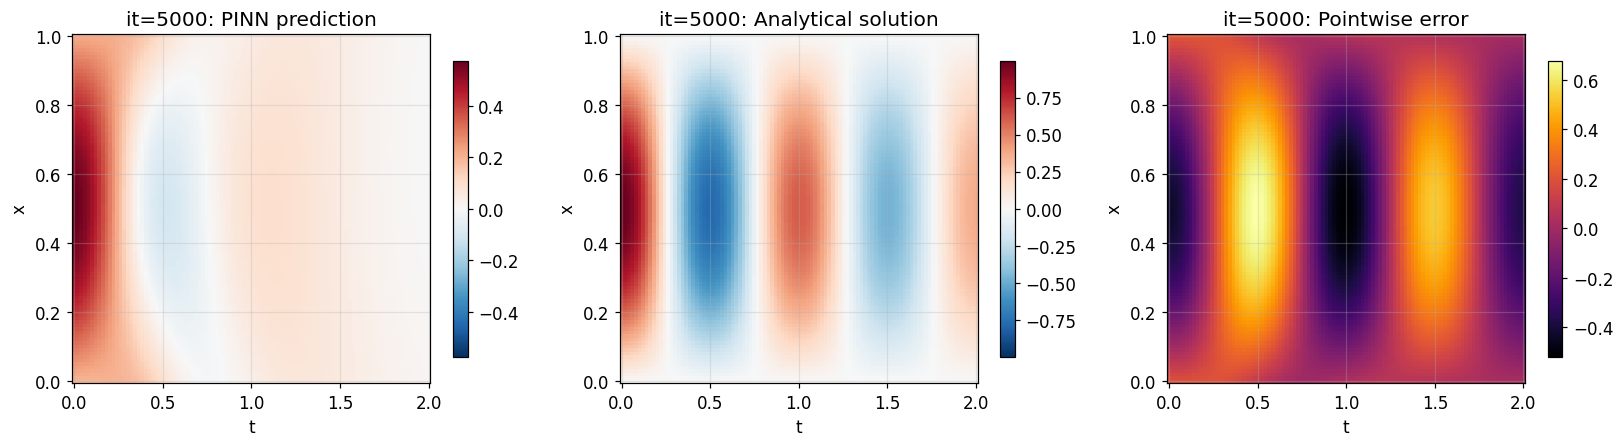

it   5000 | updated loss_weights: ['3.253', '0.401', '0.153', '0.193']
[forward] it   5100 | losses: ['4.33e-04', '4.17e-03', '1.18e-02', '1.00e-02'] | rel-L2 err: 8.405e-01
[forward] it   5200 | losses: ['4.33e-04', '4.17e-03', '1.18e-02', '1.00e-02'] | rel-L2 err: 8.311e-01
[forward] it   5300 | losses: ['4.33e-04', '4.17e-03', '1.18e-02', '1.00e-02'] | rel-L2 err: 8.179e-01
[forward] it   5400 | losses: ['4.33e-04', '4.17e-03', '1.18e-02', '1.00e-02'] | rel-L2 err: 8.191e-01
5500      [4.58e-04, 4.01e-03, 1.16e-02, 9.12e-03]    [4.64e-04, 4.01e-03, 1.16e-02, 9.12e-03]    [6.73e-01]    
[forward] it   5500 | losses: ['4.58e-04', '4.01e-03', '1.16e-02', '9.12e-03'] | rel-L2 err: 8.222e-01
it   5500 | updated loss_weights: ['3.260', '0.399', '0.151', '0.190']
[forward] it   5600 | losses: ['4.58e-04', '4.01e-03', '1.16e-02', '9.12e-03'] | rel-L2 err: 8.094e-01
[forward] it   5700 | losses: ['4.58e-04', '4.01e-03', '1.16e-02', '9.12e-03'] | rel-L2 err: 8.191e-01
[forward] it   5800 | lo

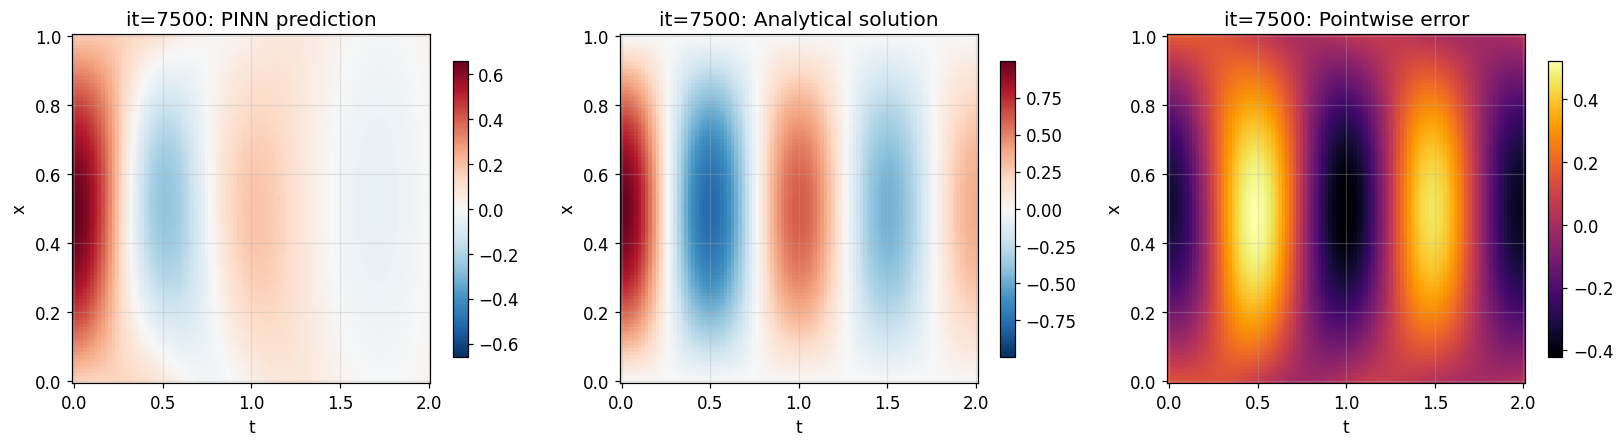

it   7500 | updated loss_weights: ['3.002', '0.567', '0.195', '0.235']
[forward] it   7600 | losses: ['7.63e-04', '3.39e-03', '9.25e-03', '1.10e-02'] | rel-L2 err: 7.111e-01
[forward] it   7700 | losses: ['7.63e-04', '3.39e-03', '9.25e-03', '1.10e-02'] | rel-L2 err: 6.826e-01
[forward] it   7800 | losses: ['7.63e-04', '3.39e-03', '9.25e-03', '1.10e-02'] | rel-L2 err: 6.616e-01
[forward] it   7900 | losses: ['7.63e-04', '3.39e-03', '9.25e-03', '1.10e-02'] | rel-L2 err: 6.618e-01
8000      [2.26e-03, 3.53e-03, 1.03e-02, 1.01e-02]    [1.66e-03, 3.53e-03, 1.03e-02, 1.01e-02]    [5.47e-01]    
[forward] it   8000 | losses: ['2.26e-03', '3.53e-03', '1.03e-02', '1.01e-02'] | rel-L2 err: 6.651e-01
it   8000 | updated loss_weights: ['2.894', '0.633', '0.218', '0.255']
[forward] it   8100 | losses: ['2.26e-03', '3.53e-03', '1.03e-02', '1.01e-02'] | rel-L2 err: 6.450e-01
[forward] it   8200 | losses: ['2.26e-03', '3.53e-03', '1.03e-02', '1.01e-02'] | rel-L2 err: 6.519e-01
[forward] it   8300 | lo

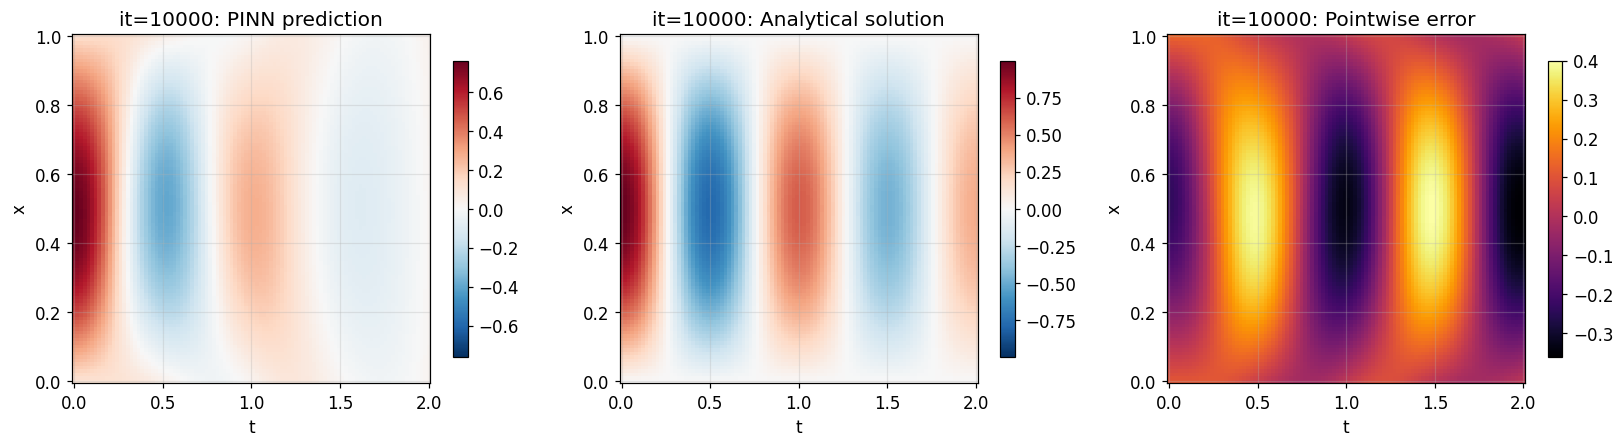

it  10000 | updated loss_weights: ['2.646', '0.790', '0.306', '0.258']
[forward] it  10100 | losses: ['4.34e-03', '2.75e-03', '5.86e-03', '1.32e-02'] | rel-L2 err: 5.524e-01
[forward] it  10200 | losses: ['4.34e-03', '2.75e-03', '5.86e-03', '1.32e-02'] | rel-L2 err: 5.530e-01
[forward] it  10300 | losses: ['4.34e-03', '2.75e-03', '5.86e-03', '1.32e-02'] | rel-L2 err: 5.381e-01
[forward] it  10400 | losses: ['4.34e-03', '2.75e-03', '5.86e-03', '1.32e-02'] | rel-L2 err: 5.446e-01
10500     [2.50e-02, 3.01e-03, 7.08e-03, 1.42e-02]    [1.99e-02, 3.01e-03, 7.08e-03, 1.42e-02]    [4.26e-01]    
[forward] it  10500 | losses: ['2.50e-02', '3.01e-03', '7.08e-03', '1.42e-02'] | rel-L2 err: 5.297e-01
it  10500 | updated loss_weights: ['2.408', '0.939', '0.372', '0.280']
[forward] it  10600 | losses: ['2.50e-02', '3.01e-03', '7.08e-03', '1.42e-02'] | rel-L2 err: 5.296e-01
[forward] it  10700 | losses: ['2.50e-02', '3.01e-03', '7.08e-03', '1.42e-02'] | rel-L2 err: 5.128e-01
[forward] it  10800 | lo

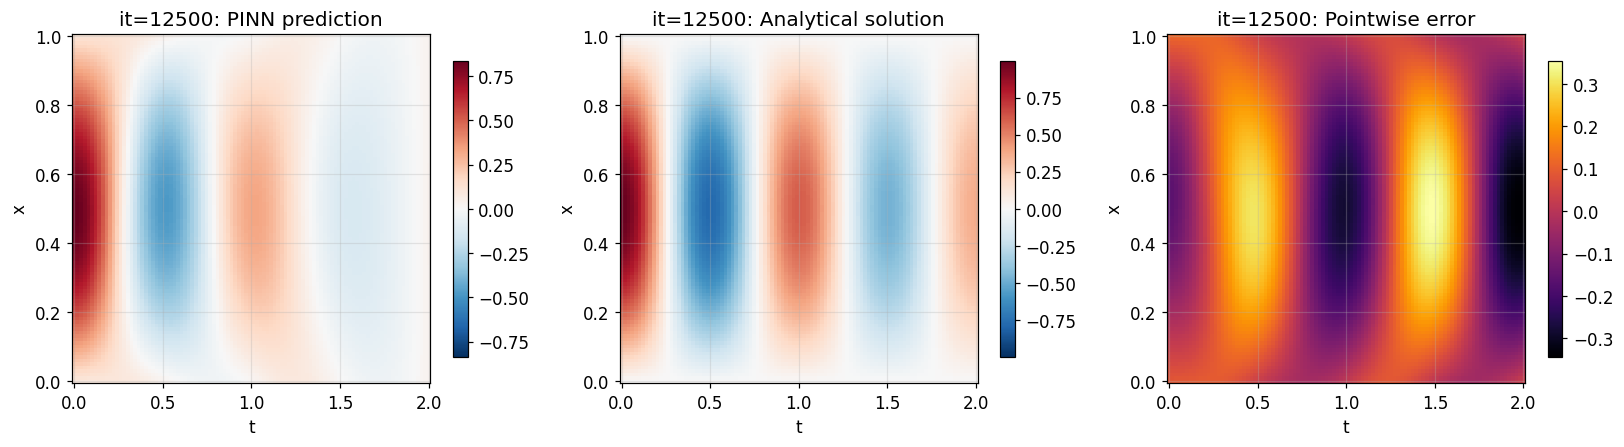

it  12500 | updated loss_weights: ['2.430', '0.904', '0.423', '0.243']
[forward] it  12600 | losses: ['7.54e-04', '2.94e-03', '4.54e-03', '1.50e-02'] | rel-L2 err: 4.709e-01
[forward] it  12700 | losses: ['7.54e-04', '2.94e-03', '4.54e-03', '1.50e-02'] | rel-L2 err: 4.597e-01
[forward] it  12800 | losses: ['7.54e-04', '2.94e-03', '4.54e-03', '1.50e-02'] | rel-L2 err: 4.652e-01
[forward] it  12900 | losses: ['7.54e-04', '2.94e-03', '4.54e-03', '1.50e-02'] | rel-L2 err: 4.601e-01
13000     [7.76e-04, 2.61e-03, 3.78e-03, 1.43e-02]    [8.38e-04, 2.61e-03, 3.78e-03, 1.43e-02]    [3.55e-01]    
[forward] it  13000 | losses: ['7.76e-04', '2.61e-03', '3.78e-03', '1.43e-02'] | rel-L2 err: 4.535e-01
it  13000 | updated loss_weights: ['2.444', '0.890', '0.433', '0.233']
[forward] it  13100 | losses: ['7.76e-04', '2.61e-03', '3.78e-03', '1.43e-02'] | rel-L2 err: 4.694e-01
[forward] it  13200 | losses: ['7.76e-04', '2.61e-03', '3.78e-03', '1.43e-02'] | rel-L2 err: 4.473e-01
[forward] it  13300 | lo

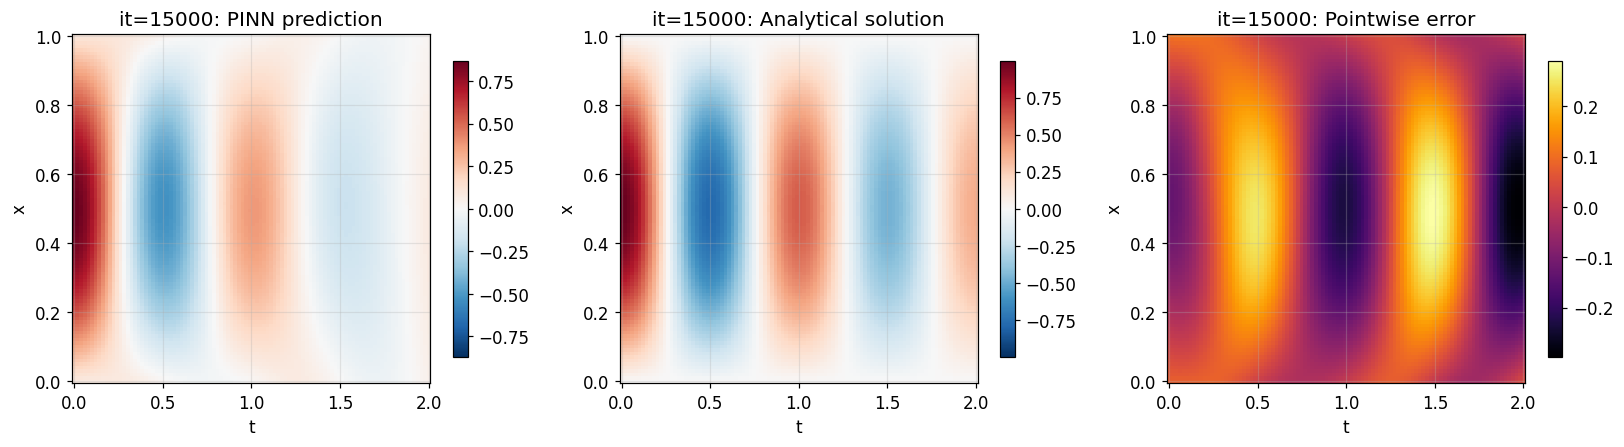

it  15000 | updated loss_weights: ['2.295', '0.950', '0.529', '0.225']

Best model at step 15000:
  train loss: 1.81e-02
  test loss: 1.83e-02
  test metric: [3.08e-01]

'train' took 299.325935 s

Compiling model...
'compile' took 0.000631 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
15000     [6.73e-04, 2.39e-03, 6.86e-03, 4.89e-02]    [7.65e-04, 2.39e-03, 6.86e-03, 4.89e-02]    [3.08e-01]    
16000     [9.23e-05, 1.42e-06, 4.64e-06, 1.29e-04]    [9.28e-05, 1.42e-06, 4.64e-06, 1.29e-04]    [2.14e-01]    
[forward] it  16000 | losses: ['9.23e-05', '1.42e-06', '4.64e-06', '1.29e-04'] | rel-L2 err: 2.856e-01
17000     [2.75e-05, 4.68e-07, 3.14e-06, 5.36e-05]    [2.93e-05, 4.68e-07, 3.14e-06, 5.36e-05]    [3.18e-01]    
[forward] it  17000 | losses: ['2.75e-05', '4.68e-07', '3.14e-06', '5.36e-05'] | rel-L2 err: 4.243e-01
18000     [1.57e-05, 2.61e-07, 3.12e-06, 2.37e-05]    [1.57e-05, 2.61e-07, 3.12e

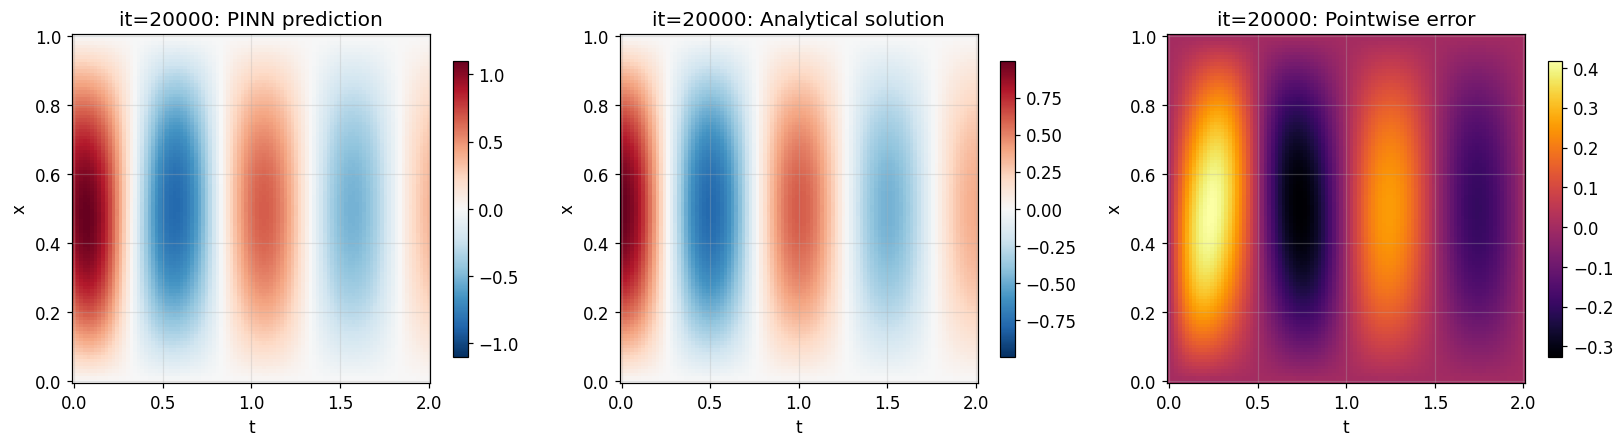

21000     [5.42e-06, 2.65e-08, 5.38e-07, 5.77e-06]    [4.97e-06, 2.65e-08, 5.38e-07, 5.77e-06]    [3.21e-01]    
[forward] it  21000 | losses: ['5.42e-06', '2.65e-08', '5.38e-07', '5.77e-06'] | rel-L2 err: 4.288e-01
21061     [5.43e-06, 2.76e-08, 5.41e-07, 5.63e-06]    [5.05e-06, 2.76e-08, 5.41e-07, 5.63e-06]    [3.19e-01]    

Best model at step 21061:
  train loss: 1.16e-05
  test loss: 1.12e-05
  test metric: [3.19e-01]

'train' took 221.367467 s


Forward training complete in 520.7 s


In [12]:
# training -> Two stage optimizers
# Adam for reaching the solution quickly &
# lbfgs with a good starting point
net_fwd = make_net()
model_fwd = dde.Model(data_fwd, net_fwd)

plotter_fwd = PeriodicPlotter(period=100, plot_period=2500, tag="forward")
soft_weights = SoftAdaptiveWeights(period=500, alpha=0.9, warmup=500)

model_fwd.compile("adam", lr=1e-3, loss_weights=[1, 1, 1, 1],
                   metrics=["l2 relative error"])
t0 = time.time()
losshistory_fwd, train_state_fwd = model_fwd.train(
    iterations=15000,
    callbacks=[plotter_fwd, soft_weights, resampler],
    display_every=500,
)

model_fwd.compile("L-BFGS", metrics=["l2 relative error"])
losshistory_fwd2, train_state_fwd2 = model_fwd.train(callbacks=[plotter_fwd])
t1 = time.time()
print(f"\nForward training complete in {t1 - t0:.1f} s")

Final relative L2 error: 4.2990e-01
Final L-infinity error:  3.8705e-01


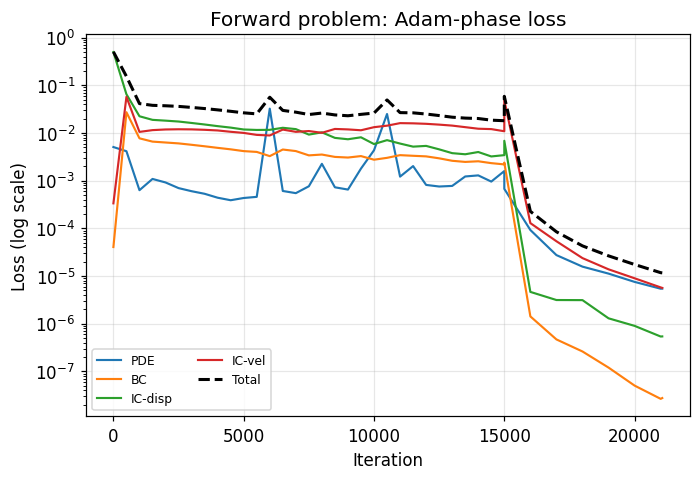

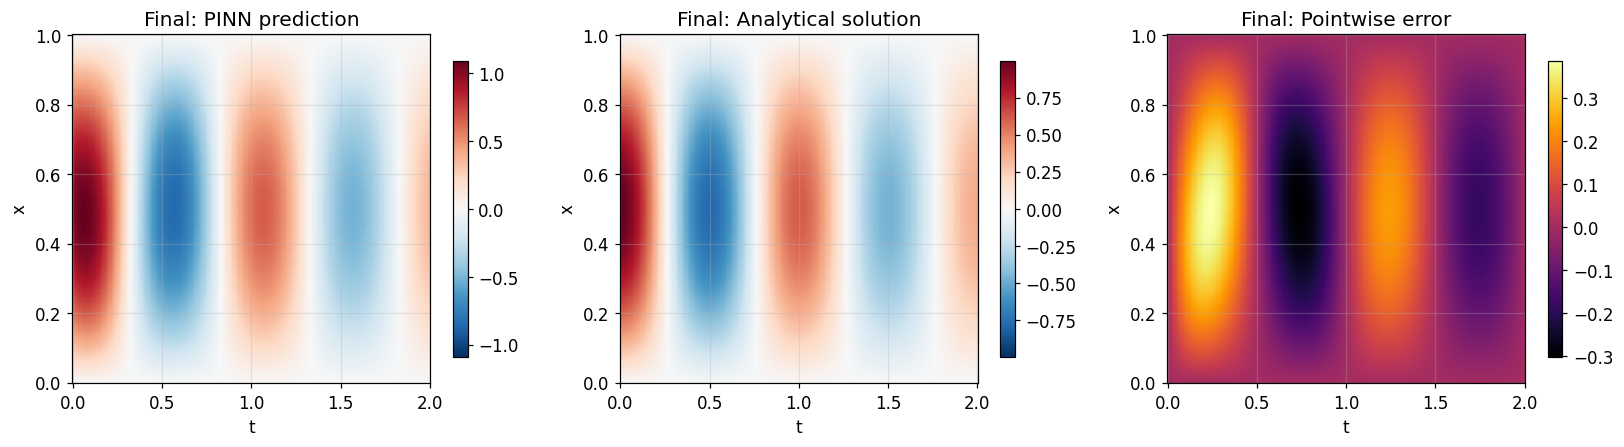

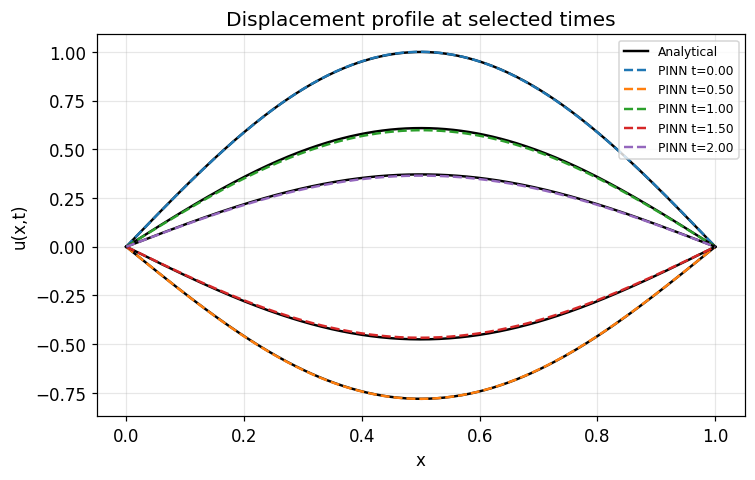

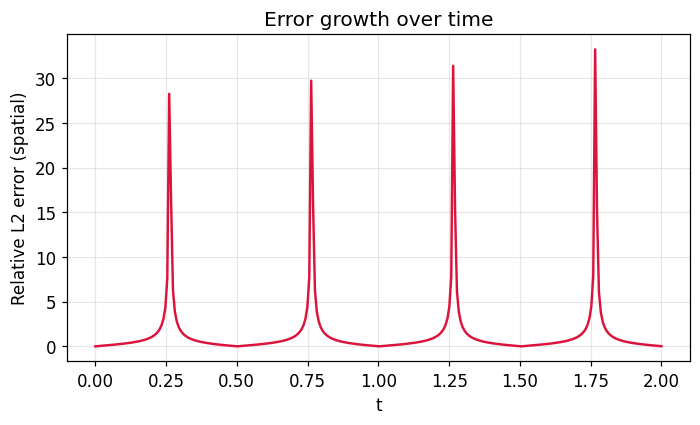

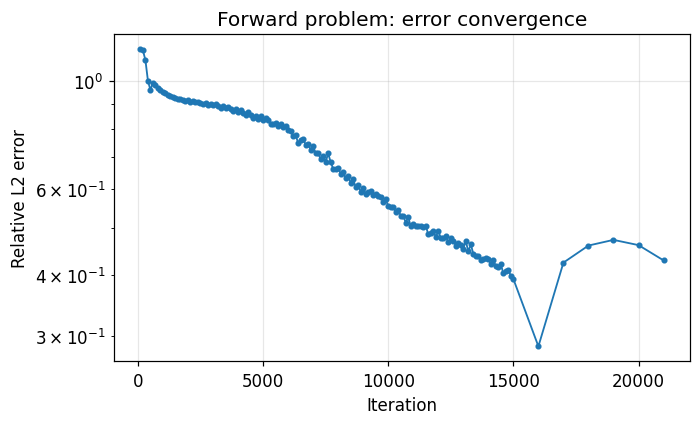

In [13]:
# validation of test data
res_fwd = compute_errors(model_fwd, nx=300, nt=300)
print(f"Final relative L2 error: {res_fwd['l2_rel']:.4e}")
print(f"Final L-infinity error:  {res_fwd['linf']:.4e}")

plot_loss_history(losshistory_fwd, title="Forward problem: Adam-phase loss", fname="fwd_loss_adam.png")
plot_solution_maps(res_fwd, title_prefix="Final: ", fname="fwd_final_maps.png")
plot_time_slices(res_fwd, fname="fwd_time_slices.png")
plot_error_vs_time(res_fwd, fname="fwd_error_vs_time.png")

# trend of L2 error over training
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
ax.semilogy(plotter_fwd.epochs, plotter_fwd.l2_errors, marker="o", ms=3, lw=1.2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Relative L2 error")
ax.set_title("Forward problem: error convergence")
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "fwd_convergence.png"))
plt.show()

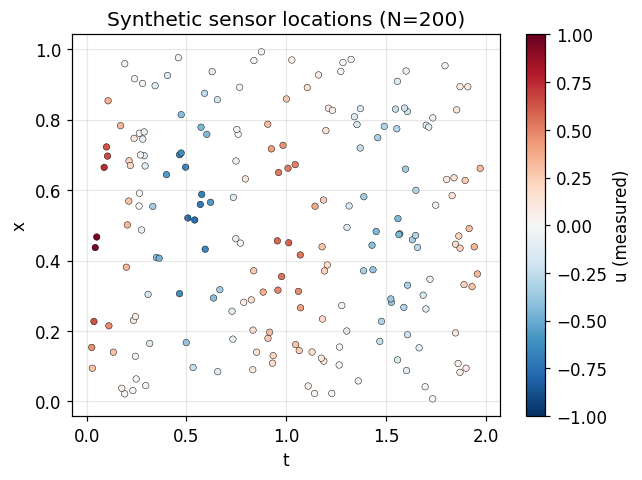

Compiling model...
'compile' took 0.000304 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [2.05e-03, 9.18e-04, 5.28e-01, 5.59e-04, 1.02e+00]    [2.05e-03, 9.18e-04, 5.28e-01, 5.59e-04, 1.02e+00]    [1.02e+00]    
[inverse] it    200 | losses: ['2.05e-03', '9.18e-04', '5.28e-01', '5.59e-04', '1.02e+00'] | rel-L2 err: 9.366e-01
[inverse] it    400 | losses: ['2.05e-03', '9.18e-04', '5.28e-01', '5.59e-04', '1.02e+00'] | rel-L2 err: 8.217e-01
[inverse] it    600 | losses: ['2.05e-03', '9.18e-04', '5.28e-01', '5.59e-04', '1.02e+00'] | rel-L2 err: 6.852e-01
[inverse] it    800 | losses: ['2.05e-03', '9.18e-04', '5.28e-01', '5.59e-04', '1.02e+00'] | rel-L2 err: 6.015e-01
1000      [1.98e-02, 2.09e-03, 4.24e-03, 3.16e-02, 2.95e-01]    [1.94e-02, 2.09e-03, 4.24e-03, 3.16e-02, 2.95e-01]    [3.96e-01]    
[inverse] it   1000 | losses: ['1.98e-02', '2.09e-03', '4.24e-03', '3.16e-02

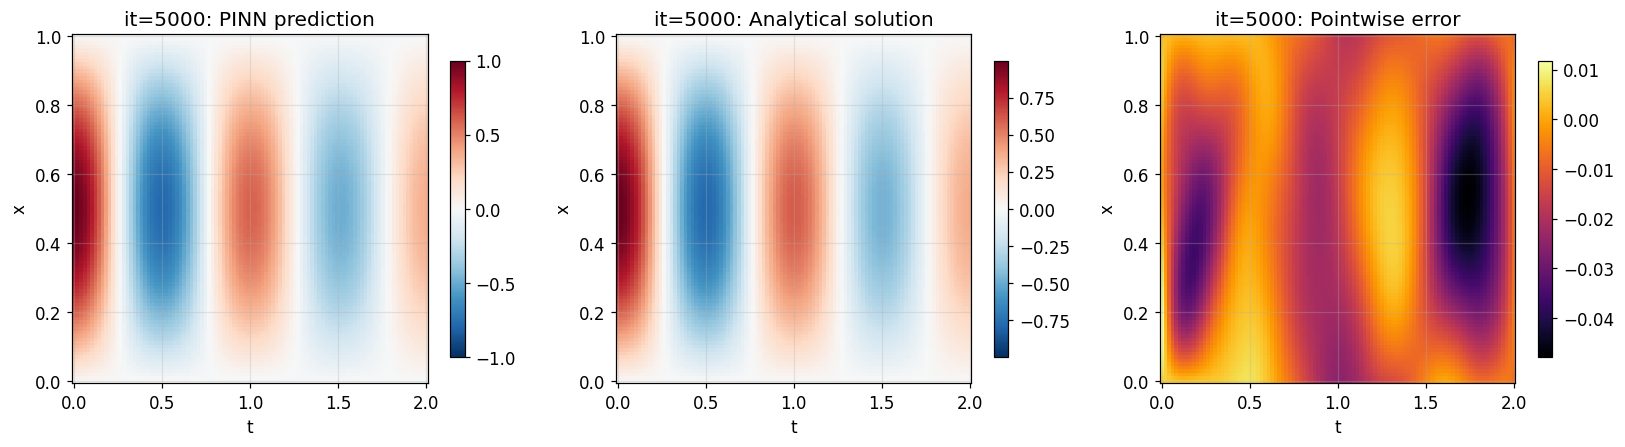

[inverse] it   5200 | losses: ['4.57e-03', '1.08e-04', '4.12e-05', '1.19e-03', '3.56e-03'] | rel-L2 err: 3.128e-02
[inverse] it   5400 | losses: ['4.57e-03', '1.08e-04', '4.12e-05', '1.19e-03', '3.56e-03'] | rel-L2 err: 3.470e-02
[inverse] it   5600 | losses: ['4.57e-03', '1.08e-04', '4.12e-05', '1.19e-03', '3.56e-03'] | rel-L2 err: 2.677e-02
[inverse] it   5800 | losses: ['4.57e-03', '1.08e-04', '4.12e-05', '1.19e-03', '3.56e-03'] | rel-L2 err: 3.217e-02
6000      [2.73e-03, 6.98e-05, 3.73e-05, 4.03e-04, 7.06e-04]    [2.97e-03, 6.98e-05, 3.73e-05, 4.03e-04, 7.06e-04]    [2.26e-02]    
[inverse] it   6000 | losses: ['2.73e-03', '6.98e-05', '3.73e-05', '4.03e-04', '7.06e-04'] | rel-L2 err: 2.715e-02
[inverse] it   6200 | losses: ['2.73e-03', '6.98e-05', '3.73e-05', '4.03e-04', '7.06e-04'] | rel-L2 err: 2.151e-02
[inverse] it   6400 | losses: ['2.73e-03', '6.98e-05', '3.73e-05', '4.03e-04', '7.06e-04'] | rel-L2 err: 2.119e-02
[inverse] it   6600 | losses: ['2.73e-03', '6.98e-05', '3.73e-

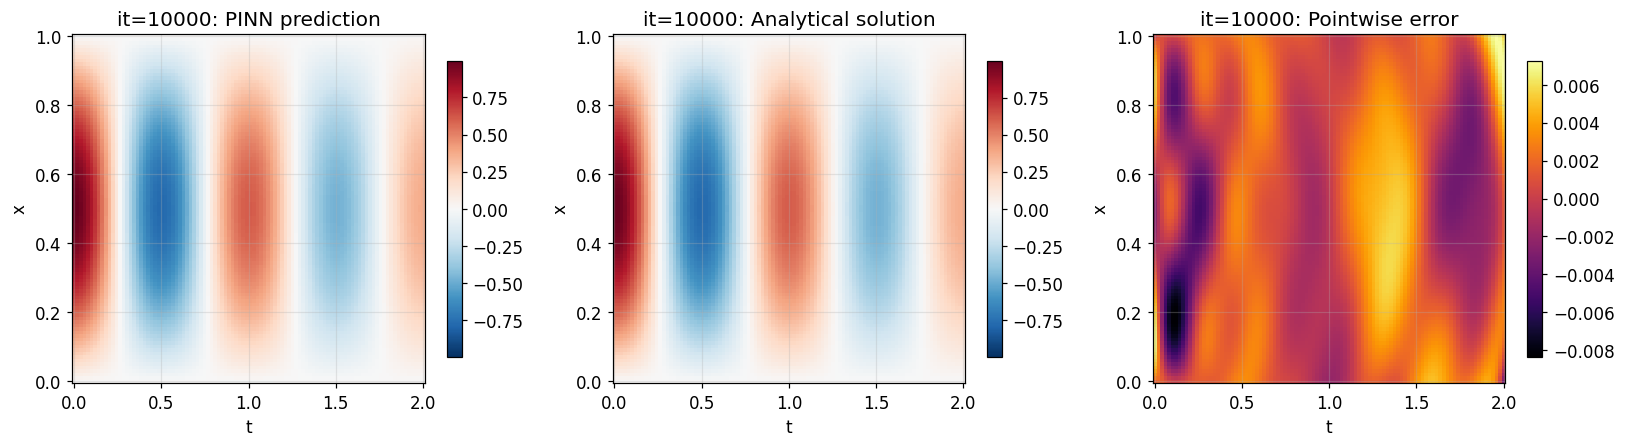

[inverse] it  10200 | losses: ['3.40e-04', '5.48e-06', '1.38e-05', '1.69e-04', '5.81e-05'] | rel-L2 err: 8.077e-03
[inverse] it  10400 | losses: ['3.40e-04', '5.48e-06', '1.38e-05', '1.69e-04', '5.81e-05'] | rel-L2 err: 8.608e-03
[inverse] it  10600 | losses: ['3.40e-04', '5.48e-06', '1.38e-05', '1.69e-04', '5.81e-05'] | rel-L2 err: 6.484e-03
[inverse] it  10800 | losses: ['3.40e-04', '5.48e-06', '1.38e-05', '1.69e-04', '5.81e-05'] | rel-L2 err: 6.154e-03
11000     [2.20e-03, 1.97e-05, 1.52e-05, 1.72e-04, 1.50e-04]    [1.97e-03, 1.97e-05, 1.52e-05, 1.72e-04, 1.50e-04]    [1.07e-02]    
[inverse] it  11000 | losses: ['2.20e-03', '1.97e-05', '1.52e-05', '1.72e-04', '1.50e-04'] | rel-L2 err: 1.221e-02
[inverse] it  11200 | losses: ['2.20e-03', '1.97e-05', '1.52e-05', '1.72e-04', '1.50e-04'] | rel-L2 err: 6.550e-03
[inverse] it  11400 | losses: ['2.20e-03', '1.97e-05', '1.52e-05', '1.72e-04', '1.50e-04'] | rel-L2 err: 8.592e-03
[inverse] it  11600 | losses: ['2.20e-03', '1.97e-05', '1.52e-

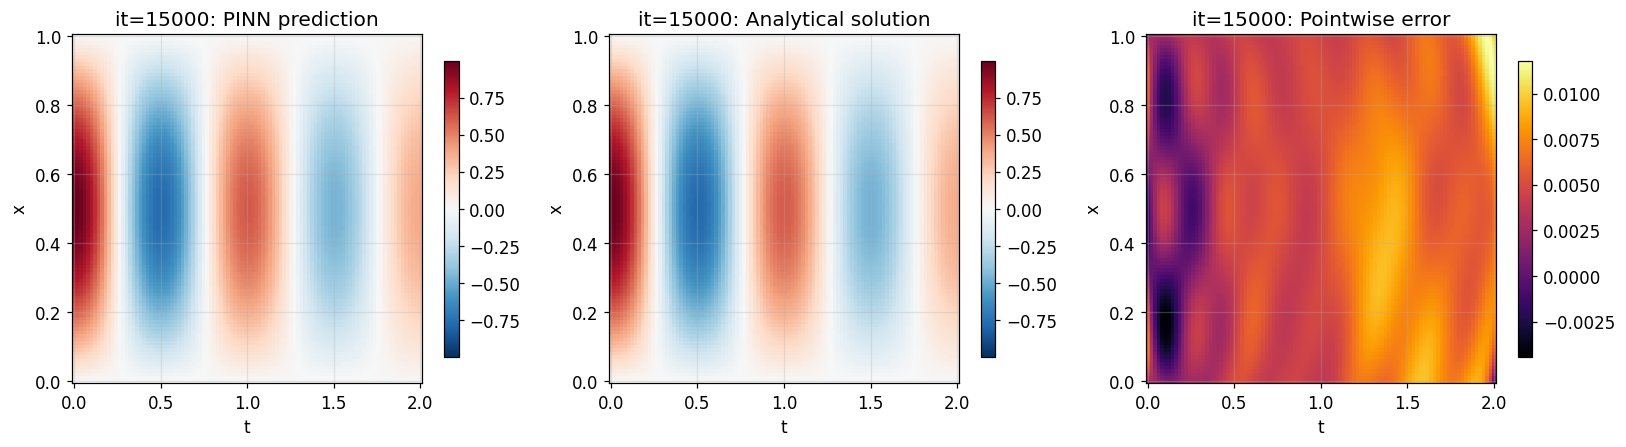

[inverse] it  15200 | losses: ['5.05e-04', '3.05e-05', '1.33e-05', '1.25e-04', '3.01e-04'] | rel-L2 err: 9.411e-03
[inverse] it  15400 | losses: ['5.05e-04', '3.05e-05', '1.33e-05', '1.25e-04', '3.01e-04'] | rel-L2 err: 1.794e-02
[inverse] it  15600 | losses: ['5.05e-04', '3.05e-05', '1.33e-05', '1.25e-04', '3.01e-04'] | rel-L2 err: 8.761e-03
[inverse] it  15800 | losses: ['5.05e-04', '3.05e-05', '1.33e-05', '1.25e-04', '3.01e-04'] | rel-L2 err: 4.356e-03
16000     [1.11e-02, 1.91e-04, 1.75e-05, 4.72e-04, 2.07e-03]    [1.12e-02, 1.91e-04, 1.75e-05, 4.72e-04, 2.07e-03]    [3.52e-02]    
[inverse] it  16000 | losses: ['1.11e-02', '1.91e-04', '1.75e-05', '4.72e-04', '2.07e-03'] | rel-L2 err: 4.309e-02
[inverse] it  16200 | losses: ['1.11e-02', '1.91e-04', '1.75e-05', '4.72e-04', '2.07e-03'] | rel-L2 err: 5.144e-03
[inverse] it  16400 | losses: ['1.11e-02', '1.91e-04', '1.75e-05', '4.72e-04', '2.07e-03'] | rel-L2 err: 6.109e-02
[inverse] it  16600 | losses: ['1.11e-02', '1.91e-04', '1.75e-

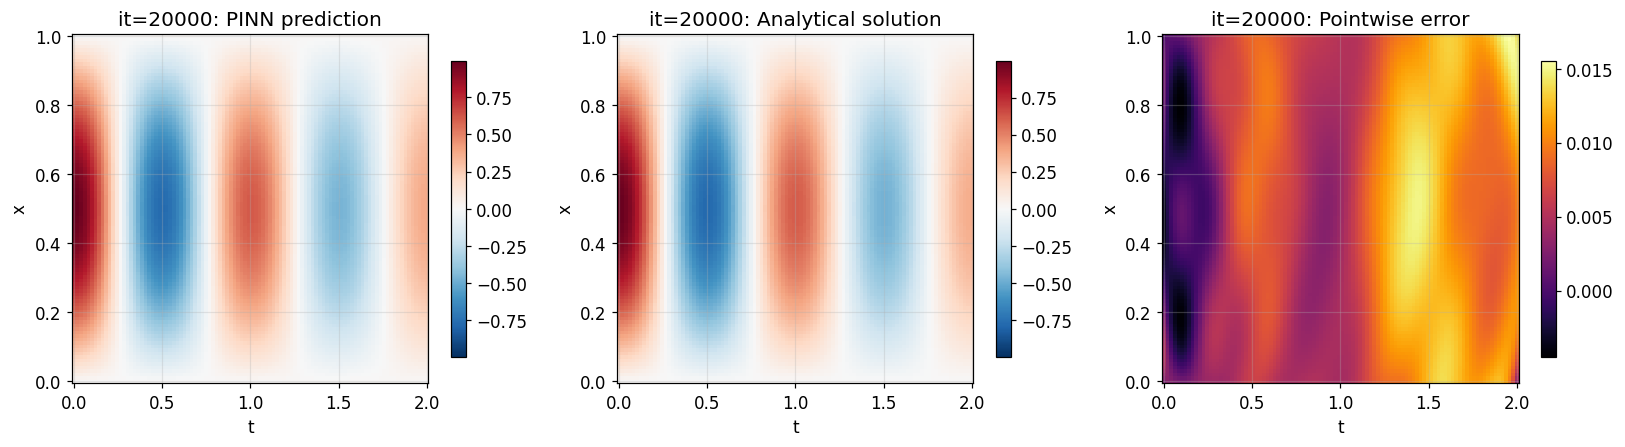


Best model at step 19000:
  train loss: 3.21e-04
  test loss: 3.81e-04
  test metric: [5.21e-03]

'train' took 390.116539 s

Compiling model...
'compile' took 0.000522 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
20000     [2.69e-03, 7.33e-05, 6.32e-06, 2.09e-04, 6.93e-05]    [2.75e-03, 7.33e-05, 6.32e-06, 2.09e-04, 6.93e-05]    [2.07e-02]    
21000     [2.41e-05, 3.12e-07, 2.16e-07, 3.50e-05, 1.38e-06]    [3.13e-05, 3.12e-07, 2.16e-07, 3.50e-05, 1.38e-06]    [2.86e-03]    
[inverse] it  21000 | losses: ['2.41e-05', '3.12e-07', '2.16e-07', '3.50e-05', '1.38e-06'] | rel-L2 err: 3.658e-03
22000     [1.41e-05, 7.31e-08, 1.53e-07, 8.89e-06, 3.08e-07]    [1.37e-05, 7.31e-08, 1.53e-07, 8.89e-06, 3.08e-07]    [1.39e-03]    
[inverse] it  22000 | losses: ['1.41e-05', '7.31e-08', '1.53e-07', '8.89e-06', '3.08e-07'] | rel-L2 err: 1.739e-03
23000     [6.92e-06, 3.16e-08, 2.12e-07, 3.81e-

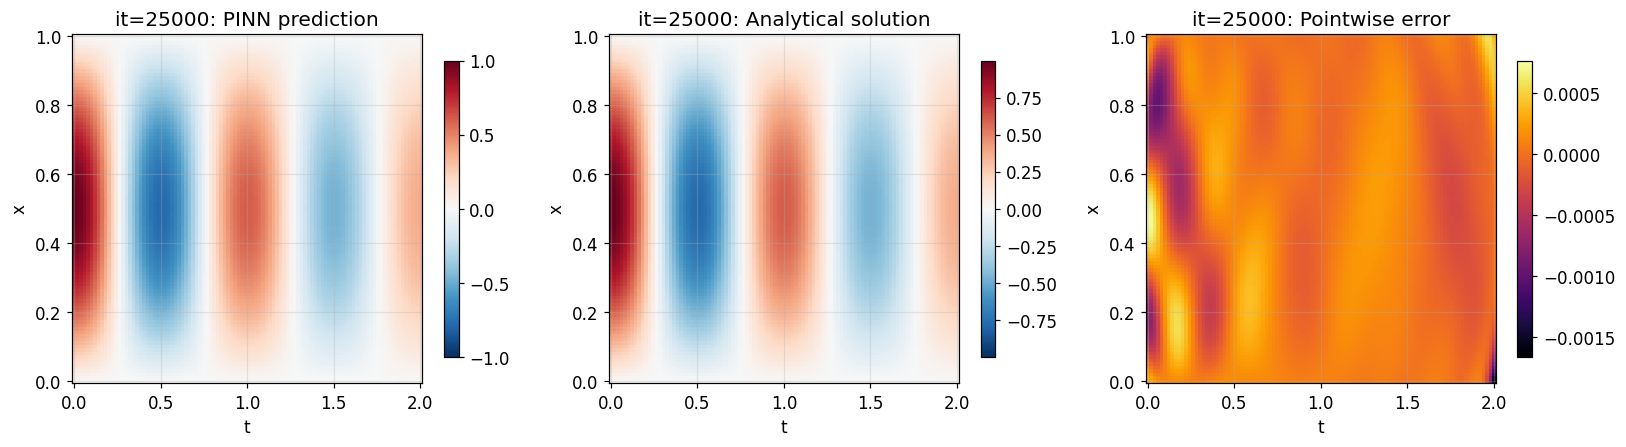

25396     [1.85e-06, 1.37e-08, 2.43e-07, 1.36e-06, 2.43e-08]    [2.04e-06, 1.37e-08, 2.43e-07, 1.36e-06, 2.43e-08]    [5.95e-04]    

Best model at step 25396:
  train loss: 3.49e-06
  test loss: 3.68e-06
  test metric: [5.95e-04]

'train' took 198.038056 s


Inverse training complete in 588.2 s
True    E = 4.0000   |  Recovered E = 3.9991   |  rel. error = 0.02%
True  eta = 0.1000   |  Recovered eta = 0.1000   |  rel. error = 0.01%


In [14]:
# synthetic data
rng = np.random.default_rng(SEED)

N_OBS = 200
x_obs = rng.uniform(0, L, N_OBS)
t_obs = rng.uniform(0, T, N_OBS)
u_obs_clean = analytical_solution(x_obs, t_obs).reshape(-1, 1)
obs_xt = np.hstack([x_obs.reshape(-1, 1), t_obs.reshape(-1, 1)])

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
sc = ax.scatter(t_obs, x_obs, c=u_obs_clean, cmap="RdBu_r", s=18,
                 vmin=-1, vmax=1, edgecolor="k", linewidth=0.3)
ax.set_xlabel("t"); ax.set_ylabel("x")
ax.set_title(f"Synthetic sensor locations (N={N_OBS})")
fig.colorbar(sc, ax=ax, label="u (measured)")
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "inverse_sensor_layout.png"))
plt.show()


E_var = dde.Variable(2.0)     # true value is 4.0
eta_var = dde.Variable(0.5)   # true value is 0.1

def pde_inverse(x, u):
    return pde(x, u, E_param=E_var, eta_param=eta_var)

def build_inverse_data(u_obs, num_domain=4000, num_boundary=200, num_initial=400):
    observe_bc = dde.icbc.PointSetBC(obs_xt, u_obs, component=0)
    return dde.data.TimePDE(
        geomtime,
        pde_inverse,
        [bc, ic_disp, ic_vel, observe_bc],
        num_domain=num_domain,
        num_boundary=num_boundary,
        num_initial=num_initial,
        anchors=obs_xt,          # force collocation set to include sensor points
        solution=analytical_solution_dde,
        num_test=2000,
    )

data_inv = build_inverse_data(u_obs_clean)
net_inv = make_net()
model_inv = dde.Model(data_inv, net_inv)


loss_weights_inv = [1, 1, 1, 1, 10]

var_history_fname = os.path.join(OUTDIR, "variables_history.dat")
variable_saver = dde.callbacks.VariableValue(
    [E_var, eta_var], period=200, filename=var_history_fname
)
plotter_inv = PeriodicPlotter(period=200, plot_period=5000, tag="inverse")

model_inv.compile("adam", lr=1e-3, loss_weights=loss_weights_inv,
                   external_trainable_variables=[E_var, eta_var],
                   metrics=["l2 relative error"])

t0 = time.time()
losshistory_inv, train_state_inv = model_inv.train(
    iterations=20000,
    callbacks=[plotter_inv, variable_saver],
    display_every=1000,
)

model_inv.compile("L-BFGS", external_trainable_variables=[E_var, eta_var],
                   metrics=["l2 relative error"])
losshistory_inv2, train_state_inv2 = model_inv.train(
    callbacks=[variable_saver, plotter_inv]
)
t1 = time.time()

E_recovered = float(E_var.detach())
eta_recovered = float(eta_var.detach())
print(f"\nInverse training complete in {t1 - t0:.1f} s")
print(f"True    E = {E_true:.4f}   |  Recovered E = {E_recovered:.4f}   "
      f"|  rel. error = {abs(E_recovered - E_true)/E_true*100:.2f}%")
print(f"True  eta = {eta_true:.4f}   |  Recovered eta = {eta_recovered:.4f}   "
      f"|  rel. error = {abs(eta_recovered - eta_true)/eta_true*100:.2f}%")

Inverse-model field relative L2 error: 4.8433e-04


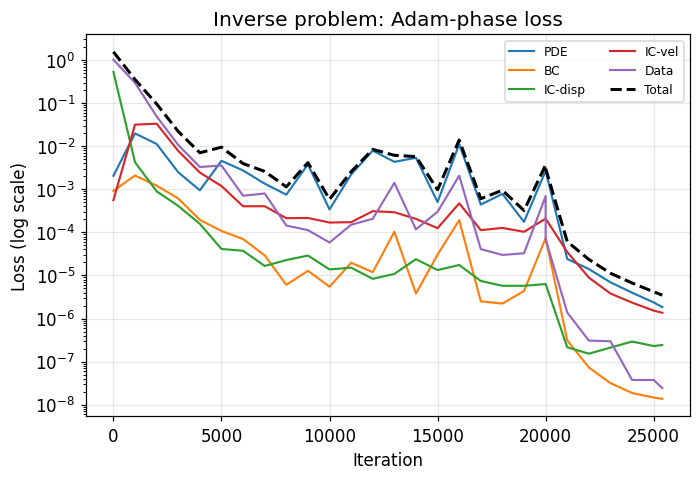

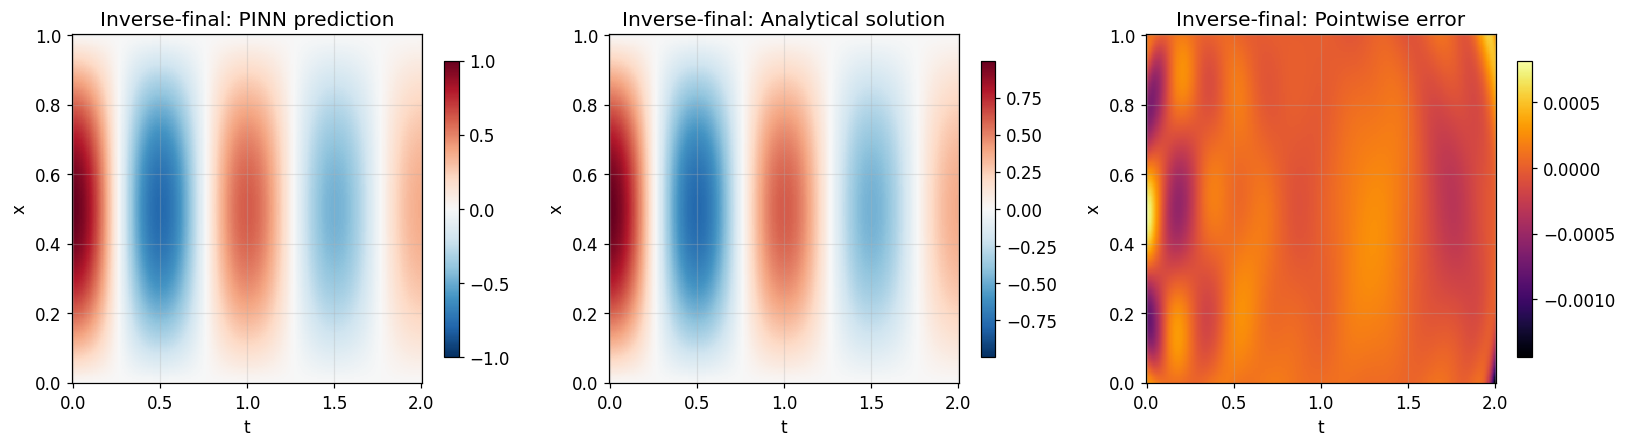

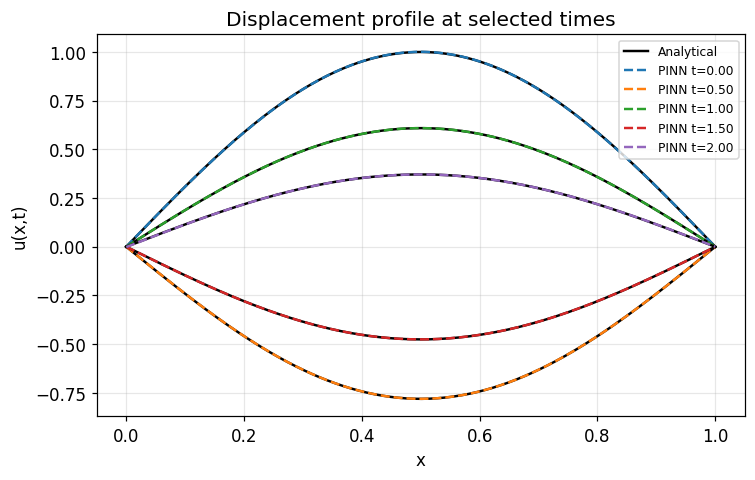

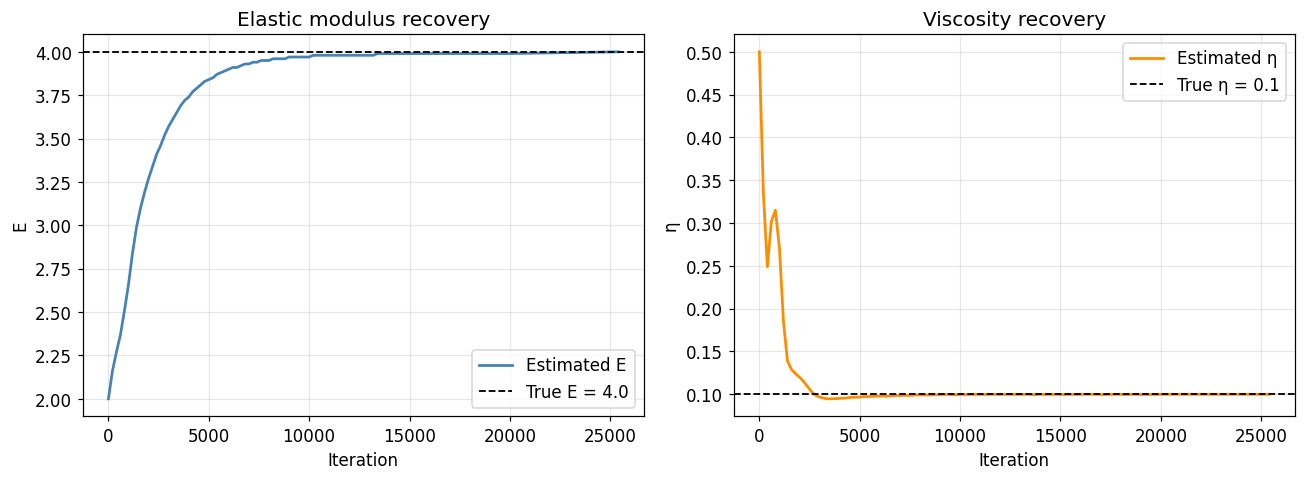

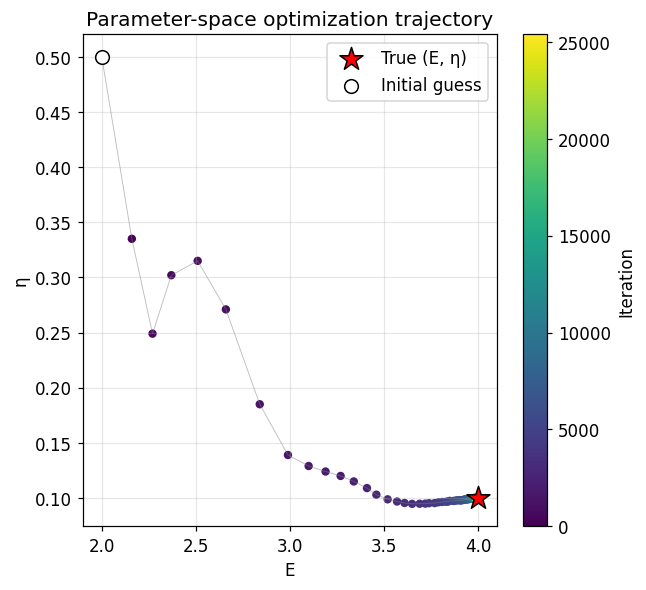

In [15]:
res_inv = compute_errors(model_inv, nx=300, nt=300)
print(f"Inverse-model field relative L2 error: {res_inv['l2_rel']:.4e}")

plot_loss_history(
    losshistory_inv, title="Inverse problem: Adam-phase loss",
    fname="inv_loss_adam.png",
    loss_names=("PDE", "BC", "IC-disp", "IC-vel", "Data")
)
plot_solution_maps(res_inv, title_prefix="Inverse-final: ", fname="inv_final_maps.png")
plot_time_slices(res_inv, fname="inv_time_slices.png")

# --- Parameter recovery trajectory (the key inverse-problem plot) ---
def load_variable_history(fname):
    steps, Es, etas = [], [], []
    with open(fname) as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            step = int(parts[0])
            vals = json.loads(parts[1])
            steps.append(step)
            Es.append(vals[0])
            etas.append(vals[1])
    return np.array(steps), np.array(Es), np.array(etas)

steps_v, E_hist, eta_hist = load_variable_history(var_history_fname)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(steps_v, E_hist, lw=1.8, color="steelblue", label="Estimated E")
axes[0].axhline(E_true, color="k", ls="--", lw=1.2, label=f"True E = {E_true}")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("E")
axes[0].set_title("Elastic modulus recovery")
axes[0].legend()

axes[1].plot(steps_v, eta_hist, lw=1.8, color="darkorange", label="Estimated η")
axes[1].axhline(eta_true, color="k", ls="--", lw=1.2, label=f"True η = {eta_true}")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("η")
axes[1].set_title("Viscosity recovery")
axes[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "inv_parameter_recovery.png"))
plt.show()

# --- Parameter-space trajectory plot (shows the optimization path) ---
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))
sc = ax.scatter(E_hist, eta_hist, c=steps_v, cmap="viridis", s=20)
ax.plot(E_hist, eta_hist, lw=0.6, color="gray", alpha=0.5)
ax.scatter([E_true], [eta_true], marker="*", s=250, color="red",
           edgecolor="k", zorder=5, label="True (E, η)")
ax.scatter([E_hist[0]], [eta_hist[0]], marker="o", s=80, color="white",
           edgecolor="k", zorder=5, label="Initial guess")
ax.set_xlabel("E"); ax.set_ylabel("η")
ax.set_title("Parameter-space optimization trajectory")
fig.colorbar(sc, ax=ax, label="Iteration")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "inv_param_trajectory.png"))
plt.show()